# AR Catalog Tutorial

Jimmy Butler, September 2024

In [7]:
import pandas as pd
import xarray as xr
import numpy as np
import os
from pathlib import Path
import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt

from 

repo_dir = str(Path(os.getcwd()).parents[0])

Dataframes are divided into years (hence just loading up the 2020 data). However, cluster labelling is consistent with previous years (so, first storm in the 2020 data will be the $n$th storm since 1980, and $n$ will be the label assigned to that storm)

In [8]:
path = repo_dir + '/data/ar_database/dataframes/2022_storm_df.h5'
storms = pd.read_hdf(path)

Each row is a storm that was identified for that particular year.

In [9]:
storms.index

Index([8099.0, 8100.0, 8101.0, 8102.0, 8103.0, 8104.0, 8105.0, 8106.0, 8107.0,
       8108.0,
       ...
       8314.0, 8315.0, 8316.0, 8317.0, 8318.0, 8319.0, 8320.0, 8321.0, 8322.0,
       8323.0],
      dtype='float64', name='cluster', length=221)

In [10]:
storms.columns

Index(['data_array', 'is_landfalling'], dtype='object')

'data_array' column consists of xarray DataArray binary masks for each storm, with time, lat, lon dimensions properly subsetted to contain the full storm.

In [11]:
storms.data_array.iloc[37]

<xarray.DataArray 'clust' (time: 38, lat: 93, lon: 253)> Size: 894kB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
...
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=int8)
Coordinates:
  * time     (time) datetime64[ns] 304B 2022-03-13T15:00:00 ... 2022-03-18T06...
  * lat      (lat) float64 744B -85.0 -84.5 -84.0 -83.5 ... -40.0 -39.5 -39.0
  * lon      (lon) float64 2kB -3.125 -2.5 -1.875 -1.25 ... 153.1 153.8 154.4

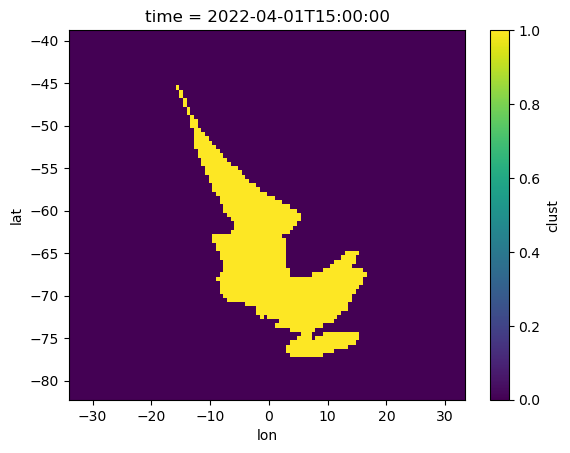

In [12]:
storms.data_array.iloc[49].isel(time=9).plot.imshow()

'is_landfalling' just indicates whether that storm makes landfall over the AIS at any point in its lifetime.

### A Note on Displaying the Catalog

By default, when displaying a DataFrame, a string representation of the stored objects will be printed out. However, since we have xArray DataArrays stored in our DataFrames, printing is extremely cumbersome and costly. Instead, if you wish to print the DataFrame, please use the custom function `display_catalog`, which takes two arguments: the dataframe, and how many rows you wish to display.

The full dataframe will be printed, but instead of a nonsense string representation of each DataArray in the `data_array` column, we get a fun thumbnail showcasing a snapshot each storm at the time of its greatest extent!